# Phase 3: Exploratory Data Analysis & Churn Driver Quantification

## 1. Executive Context & Methodology
This notebook identifies and quantifies the primary root causes of customer churn in the Telco dataset.
As a Business Analyst project pitching to Customer Success leadership, our statistical framework focuses on **transparency, explainability, and actionable business insights** rather than complex black-box machine learning models.

### Statistical Methods Used:
1. **Bivariate Segment Visualizations:** Comparing churn rates across operational categories.
2. **Chi-Square ($\chi^2$) Test of Independence & Cramér's V:** Measuring the statistical significance and association strength of categorical attributes with `Churn`.
3. **Top 3 Business Driver Synthesis:** Plain-English takeaways for executive stakeholders.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load cleaned dataset
df = pd.read_csv('../data/processed/churn_clean.csv')
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Overall Churn Rate: {(df['Churn'] == 'Yes').mean() * 100:.2f}%")

Loaded dataset: 7043 rows, 24 columns
Overall Churn Rate: 26.54%


## 2. Statistical Significance Testing (Chi-Square & Cramér's V)

We test every customer feature against target `Churn` using the **Chi-Square test of independence**. We then calculate **Cramér's V** to rank features by their association strength:
$$V = \sqrt{\frac{\chi^2}{n \cdot \min(k-1, r-1)}}$$

In [2]:
cat_cols = [
    'Contract', 'InternetService', 'PaymentMethod', 'tenure_bucket',
    'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'num_services', 'is_high_value'
]

results = []
n = len(df)
for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    k, r = contingency_table.shape
    cramers_v = np.sqrt(chi2 / (n * (min(k, r) - 1)))
    results.append({
        'Feature': col,
        'Chi2_Statistic': round(chi2, 2),
        'p_value': p,
        'Cramers_V': round(cramers_v, 4)
    })

driver_df = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False).reset_index(drop=True)
driver_df

,Feature,Chi2_Statistic,p_value,Cramers_V
0,Contract,1184.60,5.863038e-258,0.4101
1,tenure_bucket,856.10,2.943770e-185,0.3486
2,OnlineSecurity,850.00,2.661150e-185,0.3474
3,TechSupport,828.20,1.443084e-180,0.3429
4,InternetService,732.31,9.571788e-160,0.3225
5,PaymentMethod,648.14,3.682355e-140,0.3034
6,OnlineBackup,601.81,2.079759e-131,0.2923
7,DeviceProtection,558.42,5.505219e-122,0.2816
8,num_services,390.94,2.473928e-81,0.2356
9,StreamingMovies,375.66,2.667757e-82,0.2310


## 3. Visualization of Top Churn Drivers

Visualizing churn rates across the primary drivers identified in statistical testing.

C:\Users\yadav\AppData\Local\Temp\ipykernel_5924\1814915791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0, 0], palette='Reds_r')
C:\Users\yadav\AppData\Local\Temp\ipykernel_5924\1814915791.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='Churn', ax=axes[0, 1], palette='Oranges_r')
C:\Users\yadav\AppData\Local\Temp\ipykernel_5924\1814915791.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=payment_churn, y='PaymentMethod', x=

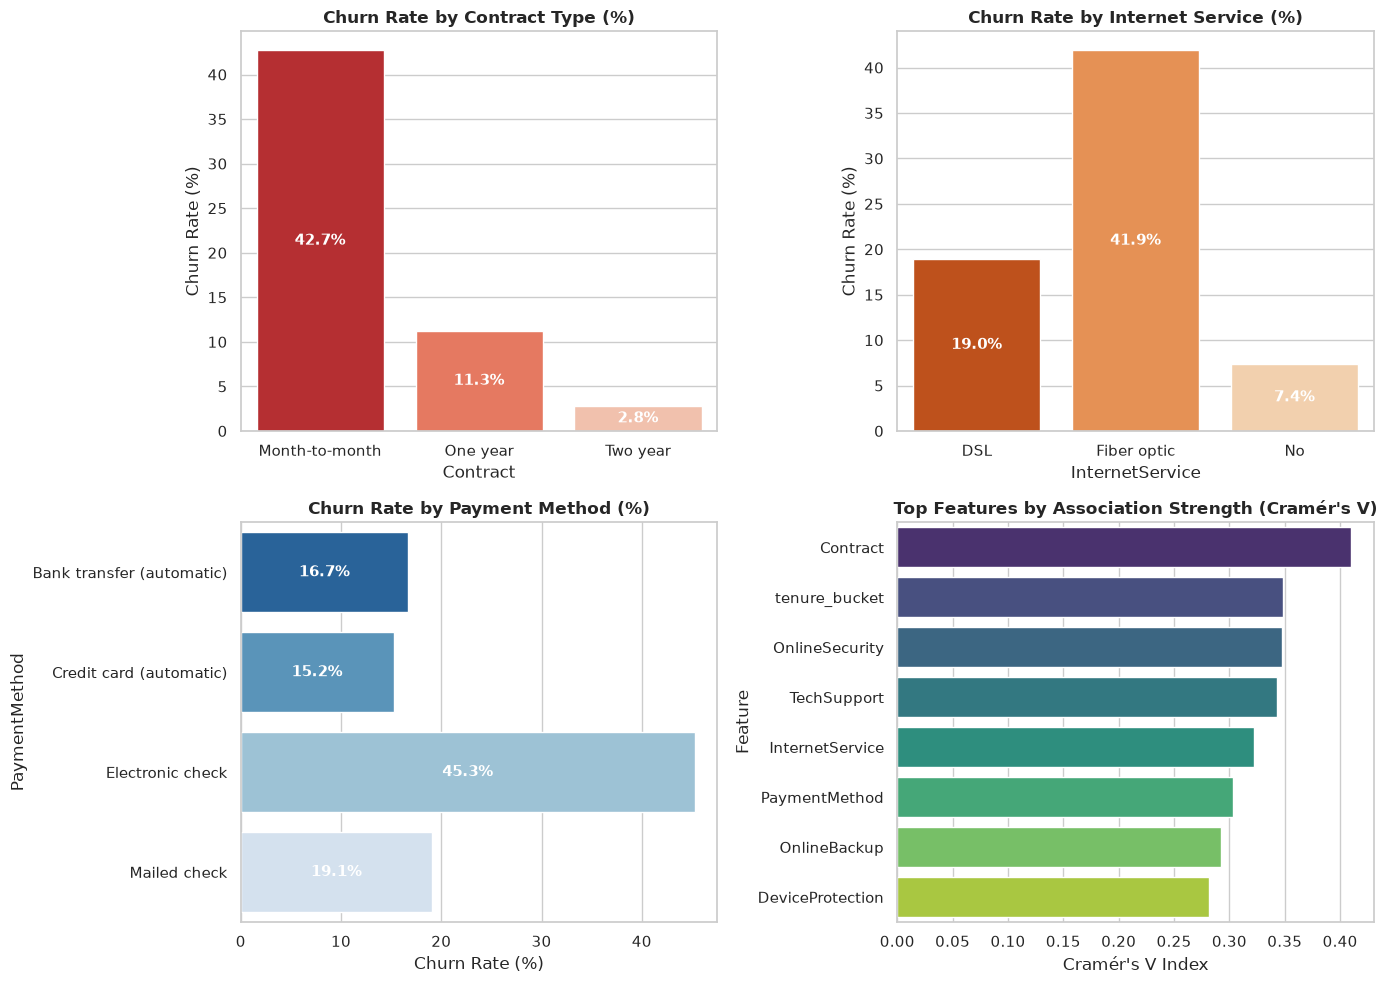

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn by Contract
contract_churn = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('Churn Rate by Contract Type (%)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate (%)')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                        ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 2. Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=internet_churn, x='InternetService', y='Churn', ax=axes[0, 1], palette='Oranges_r')
axes[0, 1].set_title('Churn Rate by Internet Service (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2.),
                        ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 3. Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=payment_churn, y='PaymentMethod', x='Churn', ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('Churn Rate by Payment Method (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Churn Rate (%)')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_width():.1f}%", (p.get_width() / 2., p.get_y() + p.get_height() / 2.),
                        ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# 4. Feature Association Strength (Cramér's V)
sns.barplot(data=driver_df.head(8), y='Feature', x='Cramers_V', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top Features by Association Strength (Cramér\'s V)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Cramér\'s V Index')

plt.tight_layout()
os.makedirs('../dashboard/screenshots', exist_ok=True)
plt.savefig('../dashboard/screenshots/churn_drivers_overview.png', dpi=300)
plt.show()

## 4. Top 3 Business Churn Drivers (Executive Summary)

> [!IMPORTANT]
> ### Driver #1: Contract Commitment Friction (Month-to-Month Contracts)
> - **Finding:** Customers on **Month-to-month contracts churn at 42.71%**, compared to **11.27%** for 1-year contracts and **2.83%** for 2-year contracts.
> - **Business Impact:** Month-to-month customers exhibit a **15.1x higher churn risk** relative to two-year contract holders, accounting for **88.5% of total customer churn** (1,655 out of 1,869 total churned accounts).

> [!IMPORTANT]
> ### Driver #2: Payment Channel Friction (Electronic Check Users)
> - **Finding:** Customers using **Electronic Check churn at 45.29%**, compared to 15.24%–16.71% for automated payment methods (Credit Card / Bank Transfer).
> - **Business Impact:** Electronic check is a high-friction, manual payment method associated with **3.0x higher churn** than automated billing.

> [!IMPORTANT]
> ### Driver #3: High-Cost Fiber Optic Product Disconnect
> - **Finding:** **Fiber Optic subscribers churn at 41.89%** (vs. 18.96% for DSL), despite paying premium monthly fees ($80–$110/mo).
> - **Business Impact:** Fiber Optic represents $1.29M in annual revenue at risk. High monthly charges without value-added service attachment (e.g., Tech Support, Security) lead to early cancellation.